# Module 1.2 — Linear Algebra for Finance
## The Geometry of Risk, Diversification, and Opportunity

---

> *"If probability is the grammar of uncertainty, linear algebra is the geometry of risk."*

Markets are not a list of prices. They are a **high-dimensional object** — and linear algebra gives you the tools to manipulate, compress, optimize, and stress that object.

In quantitative finance, nearly everything becomes a vector or a matrix:

| Object | Linear Algebra Representation |
|--------|-------------------------------|
| Portfolio allocation | Weight vector $w \in \mathbb{R}^n$ |
| Asset returns (one day) | Return vector $r_t \in \mathbb{R}^n$ |
| Historical return data | Returns matrix $R \in \mathbb{R}^{T \times n}$ |
| Portfolio risk | Quadratic form $w^\top \Sigma w$ |
| Hidden market drivers | Eigenvectors of $\Sigma$ |

This is not aesthetic abstraction. It is **operational power**: portfolio PnL becomes a dot product, risk becomes a quadratic form, diversification becomes a covariance matrix structure, and hidden factors become eigenvectors.

---

### What You Will Build in This Notebook

1. **Vectors & Matrices** — Represent portfolios and returns as mathematical objects
2. **Eigenvalues & PCA** — Discover hidden risk directions in covariance structure
3. **Quadratic Forms** — Measure risk and marginal contributions analytically
4. **Covariance Matrices** — Understand the central object of portfolio theory
5. **Markowitz Optimization** — Turn beliefs into portfolio decisions
6. **PCA for Risk Factors** — Build factor models from eigenvectors
7. **Dimensionality Reduction** — Compress signals, reduce overfitting
8. **Efficient Frontier** — Visualize the full risk-return tradeoff

---

> *"The most important skill in quant finance is not prediction. It is choosing the right mathematical representation."*


In [1]:
# need to add more mathematical description to each function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(4)

def annualize_return(mu_daily, trading_days=252):
    return (1 + mu_daily)**trading_days - 1

def annualize_vol(sigma_daily, trading_days=252):
    return sigma_daily * np.sqrt(trading_days)

def cov_to_corr(Sigma):
    d = np.sqrt(np.diag(Sigma))
    return Sigma / np.outer(d, d)

def portfolio_return(mu, w):
    return float(w @ mu)

def portfolio_variance(Sigma, w):
    return float(w @ Sigma @ w)

def portfolio_vol(Sigma, w):
    return np.sqrt(portfolio_variance(Sigma, w))

---

## 1. Vectors, Matrices, and Matrix Operations

### The Core Insight

"Thinking like a quant" means **compressing a complex market into a compact mathematical object**. Once you do that, an entire arsenal of matrix operations becomes available.

- A **portfolio** of $n$ assets is a weight vector $w \in \mathbb{R}^n$ — capital allocations as numbers
- A **day of returns** across all assets is a return vector $r_t \in \mathbb{R}^n$
- A **history of returns** is a matrix $R \in \mathbb{R}^{T \times n}$, rows = time steps, columns = assets

---

### Formal Definitions

**Portfolio weight vector** (fully invested):

$$w \in \mathbb{R}^n, \qquad \mathbf{1}^\top w = 1$$

where $w_i$ is the fraction of capital allocated to asset $i$.

**Returns matrix:**

$$R \in \mathbb{R}^{T \times n}, \qquad R = \begin{bmatrix} r_1^\top \\ r_2^\top \\ \vdots \\ r_T^\top \end{bmatrix}$$

**Portfolio return** at time $t$ — a simple dot product:

$$r_{p,t} = w^\top r_t$$

**Cumulative wealth** under simple compounding:

$$W_T = W_0 \prod_{t=1}^T (1 + r_{p,t})$$

---

### Matrix Operations as Economic Meaning

| Operation | Mathematical Form | Economic Interpretation |
|-----------|-------------------|-------------------------|
| Dot product | $w^\top r_t$ | Portfolio return at time $t$ |
| $\ell_1$ norm | $\|w\|_1 = \sum_i \|w_i\|$ | Gross exposure / leverage |
| $\ell_2$ norm | $\|w\|_2$ | Concentration penalty in optimization |
| Matrix multiply | $R w$ | Full return series for portfolio $w$ |
| Transpose | $r^\top \Sigma r$ | Inner product weighted by covariance |

---

### Why This Matters

> **Shape discipline.** Every matrix operation forces you to be explicit about what depends on what. That discipline is exactly what rigorous trading research demands.

**Key professional habits:**
- Always verify shapes before multiplying: $(T \times n) \cdot (n \times 1) = (T \times 1)$ ✓
- Treat `@` (matrix multiply) as the default; use element-wise `*` only when intentional
- Interpret results economically, not just numerically


In [2]:
# Build a returns matrix and basic operations
# Simulate T days of returns for n assets with some correlation structure
T, n = 1500, 6

# Create a random positive semi-definite covariance matrix
A = np.random.randn(n, n)
Sigma_true = (A @ A.T)  # PSD
Sigma_true = Sigma_true / np.max(np.diag(Sigma_true)) * (0.02**2)  # scale daily vols ~2%

mu_true = np.array([0.0004, 0.00035, 0.0003, 0.00045, 0.00025, 0.00038])

R = np.random.multivariate_normal(mean=mu_true, cov=Sigma_true, size=T)  # (T, n)
R = pd.DataFrame(R, columns=[f"Asset_{i+1}" for i in range(n)])

R.head(), R.shape 

# Vector of portfolio weights (sums to 1)
w = np.array([0.20, 0.15, 0.10, 0.25, 0.10, 0.20])

# Daily portfolio return series: r_p,t = r_t^T w
rp = R.values @ w

print("Portfolio mean daily return:", rp.mean())
print("Portfolio daily volatility:", rp.std(ddof=1))


# Sample mean vector: \hat{\mu} = (1/T) * sum_t r_t
mu_hat = R.mean(axis=0).values

# Sample covariance: \hat{\Sigma} = (1/(T-1)) * sum_t (r_t - \hat{\mu})(r_t - \hat{\mu})^T
Sigma_hat = R.cov().values
corr_hat = cov_to_corr(Sigma_hat)

pd.DataFrame(corr_hat, index=R.columns, columns=R.columns)

Portfolio mean daily return: 0.0003030920891633481
Portfolio daily volatility: 0.0049699768381388995


,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5,Asset_6
Asset_1,1.000000,-0.277579,-0.127488,0.808148,-0.064664,-0.404286
Asset_2,-0.277579,1.000000,-0.434967,-0.206318,0.315741,0.595681
Asset_3,-0.127488,-0.434967,1.000000,-0.112091,-0.535055,0.125529
Asset_4,0.808148,-0.206318,-0.112091,1.000000,0.302003,-0.369560
Asset_5,-0.064664,0.315741,-0.535055,0.302003,1.000000,-0.106181
Asset_6,-0.404286,0.595681,0.125529,-0.369560,-0.106181,1.000000


---

## 2. Eigenvalues, Eigenvectors, and PCA

### The Core Insight

Covariance tells us that assets move together. But **eigenvectors reveal the directions** in which they move — the hidden structure underneath the correlation matrix.

> A portfolio can be diversified across many assets and still be entirely exposed to a single hidden risk direction. Eigenvectors make that invisible concentration visible.

---

### Eigen-Decomposition

For a symmetric positive semidefinite covariance matrix $\Sigma \in \mathbb{R}^{n \times n}$:

$$\Sigma v_i = \lambda_i v_i, \qquad \Sigma = V \Lambda V^\top$$

where:

| Symbol | Meaning |
|--------|---------|
| $v_i$ | $i$-th eigenvector — a "principal risk direction" |
| $\lambda_i$ | $i$-th eigenvalue — variance carried in direction $v_i$ |
| $V = [v_1, \dots, v_n]$ | Orthonormal matrix: $V^\top V = I$ |
| $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_n)$ | Diagonal eigenvalue matrix, $\lambda_1 \ge \lambda_2 \ge \cdots \ge 0$ |

**Total variance** is preserved under rotation:

$$\text{tr}(\Sigma) = \sum_{i=1}^n \lambda_i$$

**Variance explained** by the first $k$ components:

$$\frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^n \lambda_i}$$

---

### Principal Component Analysis (PCA)

PCA rotates the return data into the eigen-basis. For centered returns $X = R - \mathbf{1}\hat{\mu}^\top$:

$$F_k = X V_k \in \mathbb{R}^{T \times k}, \qquad V_k = [v_1, \dots, v_k]$$

The columns of $F_k$ are the **principal component time series** — uncorrelated factors ordered by variance explained.

**Typical economic interpretation in equities:**

| Component | Often represents |
|-----------|-----------------|
| PC1 | Broad market mode (all assets up/down together) |
| PC2 | Large-cap vs. small-cap tilt |
| PC3 | Sector rotation / style factor |
| PC4+ | Idiosyncratic / noise |

---

### Why This Matters

- **Risk concentration**: Portfolio exposure to $\text{PC}_k$ is $a_k = w^\top v_k$. A diversified portfolio with large $a_1$ is not truly diversified — it is a market bet.
- **Regime detection**: When the leading eigenvalue $\lambda_1$ spikes, the market is becoming one-dimensional — a classic early-crisis signal.
- **Factor stress testing**: "What happens if PC1 drops 3 standard deviations?" is a precise, actionable question.

> **Philosophical insight:** Eigenvectors teach that *risk is directional*, not merely scalar. Knowing your eigenvalue exposure is more honest than knowing your individual asset volatilities.


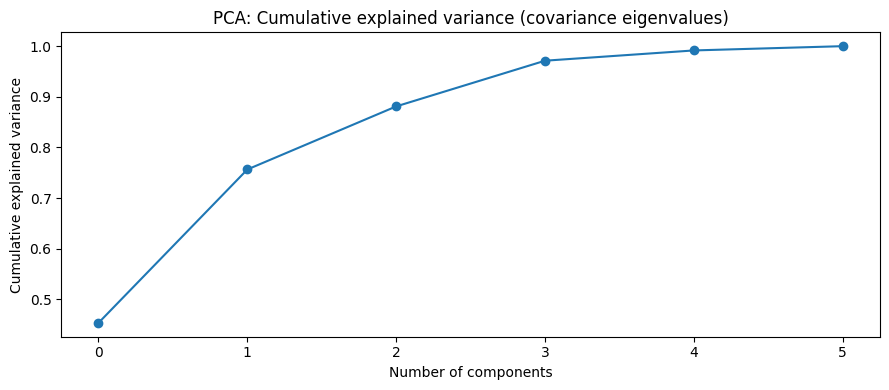

In [3]:
# Eigen-decomposition of covariance and PCA explained variance
# Eigen-decomposition of sample covariance
eigvals, eigvecs = np.linalg.eigh(Sigma_hat)  # eigh for symmetric matrices
# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

explained = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained)

pd.DataFrame({
    "eigenvalue": eigvals,
    "explained_var_ratio": explained,
    "cum_explained": cum_explained
})

# PC time series and factor exposures
X = R.values - R.values.mean(axis=0, keepdims=True)

k = 3
F = X @ eigvecs[:, :k]  # principal component factors

factor_df = pd.DataFrame(F, columns=[f"PC{i+1}" for i in range(k)])
factor_df.head()

plt.figure(figsize=(9,4))
plt.plot(cum_explained, marker="o")
plt.title("PCA: Cumulative explained variance (covariance eigenvalues)")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.tight_layout()
plt.show()

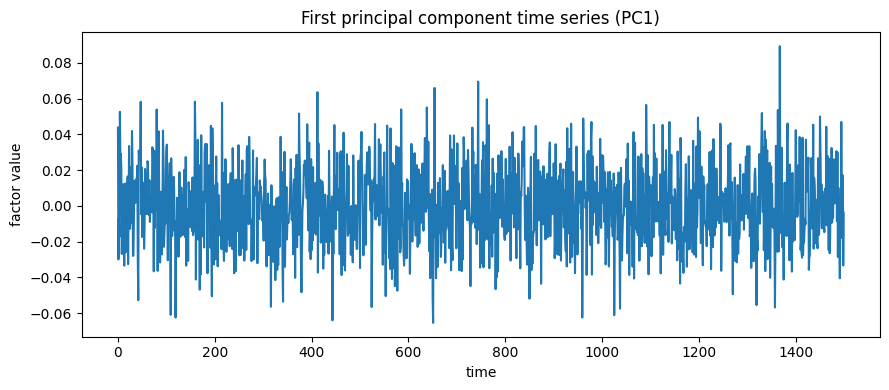

PC1   -0.093331
PC2   -0.033337
Name: Portfolio exposure, dtype: float64

In [4]:
# PCA factor returns (principal component time series)
# Center returns
X = R.values - R.values.mean(axis=0, keepdims=True)

# Principal component time series: factor_t = X_t @ v_k
k = 2
factors = X @ eigvecs[:, :k]  # (T, k)

factor_df = pd.DataFrame(factors, columns=[f"PC{i+1}" for i in range(k)])
factor_df.head()

plt.figure(figsize=(9,4))
plt.plot(factor_df["PC1"].values)
plt.title("First principal component time series (PC1)")
plt.xlabel("time")
plt.ylabel("factor value")
plt.tight_layout()
plt.show()


# Portfolio exposure to PCs: a_k = w^T v_k
exposure = w @ eigvecs[:, :k]
pd.Series(exposure, index=[f"PC{i+1}" for i in range(k)], name="Portfolio exposure")

---

## 3. Optimization and Quadratic Forms

### The Core Insight

Portfolio risk is inherently **quadratic** — not linear, not additive. The variance of a portfolio is:

$$\text{Var}(r_p) = w^\top \Sigma w = \sum_{i=1}^n \sum_{j=1}^n w_i w_j \Sigma_{ij}$$

Every pair of assets $(i, j)$ contributes through their covariance. **You cannot understand portfolio risk by summing individual risks.** Risk is relational — it lives in the off-diagonal terms.

> *"Risk is not additive. It is a quadratic form."*

---

### Quadratic Forms and Risk Geometry

The expression $w^\top \Sigma w$ defines an **ellipsoid** in weight space:

$$\{w : w^\top \Sigma w \le c\} \quad \text{— a risk-budget set}$$

Because $\Sigma \succeq 0$ (positive semidefinite), this quadratic form is **convex in $w$**, which guarantees that portfolio optimization is tractable — there are no local minima to get trapped in.

**Marginal contribution to risk:**

$$\frac{\partial}{\partial w_i}(w^\top \Sigma w) = 2(\Sigma w)_i$$

**Component contribution to variance** for asset $i$:

$$\text{CV}_i = w_i \cdot (\Sigma w)_i, \qquad \sum_{i=1}^n \text{CV}_i = w^\top \Sigma w$$

This decomposition tells you which assets are actually driving portfolio risk — a critical tool for risk management and position sizing.

---

### Portfolio Optimization (Markowitz)

The canonical **minimum variance** problem at target return $r_{\text{target}}$:

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1, \quad \mu^\top w = r_{\text{target}}, \quad w \ge 0 \; \text{(long-only)}$$

| Constraint | Economic Meaning |
|-----------|-----------------|
| $\mathbf{1}^\top w = 1$ | Fully invested — all capital deployed |
| $\mu^\top w = r_{\text{target}}$ | Return requirement |
| $w \ge 0$ | Long-only — no short selling |
| $w_i \le L_i$ | Position limits / concentration limits |

---

### The Professional Warning

> **Optimization is a magnifier.** Errors in $\hat{\mu}$ and $\hat{\Sigma}$ are amplified into extreme portfolio weights. This is not a numerical nuisance — it is a fundamental limitation.

The professional response:
- **Constrain** the weight space to prevent extreme positions
- **Shrink** the covariance estimate toward a structured target
- **Regularize** the return estimate (or avoid it entirely — use minimum variance)
- **Stress test** optimized portfolios before deploying capital

> **Philosophical insight:** Optimization forces you to write down exactly what you believe, then confront the consequences of those beliefs in PnL space. It is an honesty machine.


In [25]:
# Risk as a quadratic form + contribution intuition
# Portfolio variance from quadratic form
var_p = portfolio_variance(Sigma_hat, w)
vol_p = np.sqrt(var_p)

print("Portfolio daily variance:", var_p)
print("Portfolio daily volatility:", vol_p)

# Marginal contribution to risk: Sigma w (not normalized)
marginal = Sigma_hat @ w  # ∂(w^T Σ w)/∂w = 2 Σ w (up to factor 2)
# Component contribution to variance: w_i * (Sigma w)_i
component_var = w * marginal
pd.DataFrame({
    "weight": w,
    "marginal_risk": marginal,
    "component_var_contrib": component_var
}, index=R.columns)



Portfolio daily variance: 4.7612847834447875e-05
Portfolio daily volatility: 0.006900206361729182


,weight,marginal_risk,component_var_contrib
Asset_1,0.20,0.000063,0.000013
Asset_2,0.15,0.000011,0.000002
Asset_3,0.10,0.000056,0.000006
Asset_4,0.25,0.000047,0.000012
Asset_5,0.10,-0.000024,-0.000002
Asset_6,0.20,0.000091,0.000018


---

## 4. Covariance Matrices in Portfolio Theory

### The Core Insight

The **covariance matrix $\Sigma$** is the single most important object in classical portfolio theory. It encodes not only how risky each asset is, but how risks interact across the entire portfolio.

$$\Sigma = \mathbb{E}\left[(r - \mu)(r - \mu)^\top\right] \in \mathbb{R}^{n \times n}$$

| Entry | Meaning |
|-------|---------|
| $\Sigma_{ii}$ | Variance of asset $i$ — individual risk |
| $\Sigma_{ij}$ | Covariance of assets $i$ and $j$ — co-movement |
| $\rho_{ij} = \frac{\Sigma_{ij}}{\sqrt{\Sigma_{ii}\Sigma_{jj}}}$ | Correlation — normalized co-movement $\in [-1, 1]$ |

In a diversified portfolio, **off-diagonal terms dominate** the portfolio variance. Individual volatilities matter less than the structure of their interactions.

---

### Correlation Tightening in Crises

A well-documented empirical phenomenon:

$$\rho_{\text{crisis}} > \rho_{\text{normal}}$$

During market stress — forced liquidations, margin calls, flight to quality — assets that appeared uncorrelated begin moving together. Diversification benefits **shrink exactly when they are needed most**.

> This is not a flaw in portfolio theory. It is a feature of the world. The covariance matrix is **regime-dependent**.

---

### Factor Structure of Covariance

With many assets and finite data, $\hat{\Sigma}$ becomes noisy as $n/T$ grows. The professional solution is a **factor model**:

$$\Sigma \approx B \Sigma_f B^\top + D$$

| Symbol | Meaning |
|--------|---------|
| $B \in \mathbb{R}^{n \times k}$ | Factor loadings — how each asset loads on each factor |
| $\Sigma_f \in \mathbb{R}^{k \times k}$ | Factor covariance matrix |
| $D$ | Diagonal idiosyncratic risk (asset-specific noise) |

**Benefits of factor structure:**
- Reduces $O(n^2)$ free parameters to $O(nk)$
- Enforces interpretable structure (market, sector, style)
- Stabilizes matrix inversion for optimization
- Enables faster updates with new data

---

### Estimation Is a Belief

> **$\Sigma$ is not just a statistic. It is your encoded belief about how assets will co-move in the future.**

Practical considerations:
- **Rolling windows**: Use recent data; longer windows are more stable but less responsive
- **Shrinkage** (Ledoit–Wolf): Blend sample $\hat{\Sigma}$ with a structured target to reduce noise
- **Exponential weighting**: Down-weight older observations for faster regime adaptation
- **Regime conditioning**: Estimate separate $\Sigma$ for calm vs. stressed regimes

Markets punish stale beliefs. A covariance model that worked last year may mislead you today.


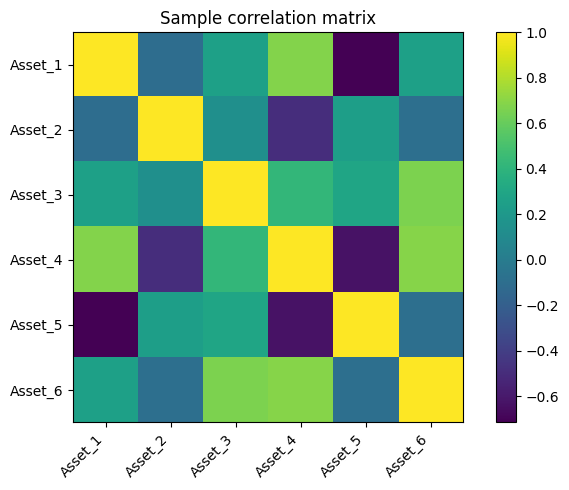

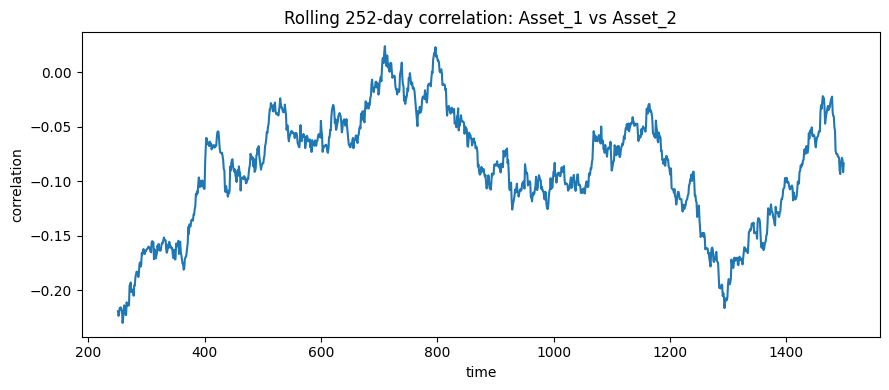

In [26]:
# Visualize correlation matrix (heatmap)  + rolling correlation intuition
corr = pd.DataFrame(corr_hat, index=R.columns, columns=R.columns)

plt.figure(figsize=(7,5))
plt.imshow(corr.values)
plt.title("Sample correlation matrix")
plt.xticks(range(n), R.columns, rotation=45, ha="right")
plt.yticks(range(n), R.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


# Rolling correlation example (Asset_1 vs Asset_2)
roll = 252
rolling_corr = R["Asset_1"].rolling(roll).corr(R["Asset_2"])

plt.figure(figsize=(9,4))
plt.plot(rolling_corr.values)
plt.title(f"Rolling {roll}-day correlation: Asset_1 vs Asset_2")
plt.xlabel("time")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

---

## 5. Portfolio Optimization Using Matrix Algebra (Markowitz, Long-Only)

### The Core Insight

Markowitz portfolio theory formalizes a single professional intuition:

> **You should not chase return without pricing the risk required to obtain it.**

Given estimates $(\hat{\mu}, \hat{\Sigma})$, every portfolio $w$ maps to a point in risk-return space:

$$\text{Expected return:} \quad \hat{\mu}^\top w \qquad\qquad \text{Variance:} \quad w^\top \hat{\Sigma} w$$

The **efficient frontier** is the set of portfolios that minimize variance for a given return level — the Pareto boundary of this tradeoff.

---

### The Optimization Problem

$$\min_w \; w^\top \hat{\Sigma} w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1, \quad \hat{\mu}^\top w = r_{\text{target}}, \quad w \in \mathcal{W}$$

where $\mathcal{W}$ encodes practical constraints:

| Constraint Set | Meaning |
|----------------|---------|
| $w \ge 0$ | Long-only |
| $\|w\|_1 \le L$ | Gross leverage limit |
| $w_i \le c_i$ | Individual position caps |
| $\sum_{i \in S} w_i \le s$ | Sector exposure limits |

Changing $\mathcal{W}$ reshapes the geometry and thus changes the frontier — the frontier is **only as real as the model and constraints behind it**.

---

### Approximating the Frontier

Without an external solver, we approximate the frontier by **sampling many feasible portfolios** from the weight simplex and keeping the minimum-variance portfolio at each return level. This builds geometric intuition:

- The frontier is a **curve**, not a point
- Every point on the frontier is a specific set of weights $w$
- Moving along the frontier means accepting more risk for more return
- There is no way to step *outside* the frontier without changing assumptions

---

### The Professional Warning

> **Optimization is not a solution — it is a translation.** It translates your beliefs $(\hat{\mu}, \hat{\Sigma})$ into weights $w$. If your beliefs are wrong, the weights will be confidently wrong.

Common failure modes:

| Failure Mode | What Happens |
|--------------|-------------|
| Noisy $\hat{\mu}$ | Optimizer chases estimation error, produces extreme weights |
| Noisy $\hat{\Sigma}$ | Near-singular matrix causes instability |
| No constraints | Leverage explodes; results are impractical |
| In-sample optimization | Perfect on backtest, poor out-of-sample |

**Professional remedies:** shrinkage, robust estimation, constraints, walk-forward validation, and treating optimized weights as **hypotheses** to stress-test — not answers to deploy blindly.


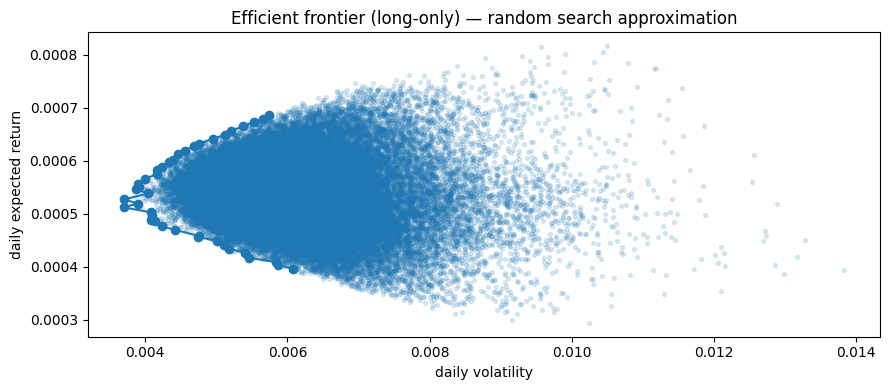

Asset_1    0.338050
Asset_2    0.008181
Asset_3    0.245028
Asset_4    0.027993
Asset_5    0.089684
Asset_6    0.291064
Name: w* (approx max Sharpe on frontier), dtype: float64

In [17]:
# Efficient frontier (long-only) via simple constrained search
# Estimate mu and Sigma from simulated data
mu = mu_hat
Sigma = Sigma_hat

def random_simplex(n, m):
    """m samples from simplex: w>=0, sum w=1"""
    x = np.random.rand(m, n)
    x = x / x.sum(axis=1, keepdims=True)
    return x

m = 60000
W = random_simplex(n, m)

# Compute portfolio returns and vols
port_rets = W @ mu
port_vars = np.einsum('ij,jk,ik->i', W, Sigma, W)  # w^T Sigma w for each row
port_vols = np.sqrt(port_vars)

# Efficient frontier approximation: for each return bucket, keep min vol
bins = 40
ret_min, ret_max = np.quantile(port_rets, 0.01), np.quantile(port_rets, 0.99)
edges = np.linspace(ret_min, ret_max, bins+1)

frontier = []
for i in range(bins):
    mask = (port_rets >= edges[i]) & (port_rets < edges[i+1])
    if mask.sum() < 50:
        continue
    j = np.argmin(port_vols[mask])
    idx_j = np.where(mask)[0][j]
    frontier.append((port_rets[idx_j], port_vols[idx_j], W[idx_j]))

frontier_rets = np.array([x[0] for x in frontier])
frontier_vols = np.array([x[1] for x in frontier])

plt.figure(figsize=(9,4))
plt.scatter(port_vols, port_rets, alpha=0.15, s=8)
plt.plot(frontier_vols, frontier_rets, marker="o")
plt.title("Efficient frontier (long-only) — random search approximation")
plt.xlabel("daily volatility")
plt.ylabel("daily expected return")
plt.tight_layout()
plt.show()

best_idx = np.argmax(frontier_rets / frontier_vols)  # max Sharpe with rf~0 (approx)
w_star = frontier[best_idx][2]
pd.Series(w_star, index=R.columns, name="w* (approx max Sharpe on frontier)")

---

## 6. Principal Component Analysis for Risk Factors

### The Core Insight

PCA provides a principled way to discover **latent factors** — the unobservable forces that drive co-movement across assets. These factors often correspond to interpretable economic drivers.

> A portfolio can hold 100 stocks and still be a pure market bet if its weights align with the first eigenvector of $\Sigma$. PCA makes that hidden exposure explicit.

---

### From Covariance to Factors

Given the eigen-decomposition $\Sigma = V\Lambda V^\top$, projecting centered returns onto the first $k$ eigenvectors:

$$F_k = X V_k, \qquad X = R - \mathbf{1}\hat{\mu}^\top$$

produces factor time series $F_k \in \mathbb{R}^{T \times k}$ with the following properties:

- **Orthogonal**: $\text{Cov}(F_k) \approx \Lambda_k = \text{diag}(\lambda_1, \dots, \lambda_k)$
- **Ordered by variance**: PC1 explains the most variance, PC2 the next most, etc.
- **Uncorrelated by construction**: factors do not overlap

**Portfolio exposure to PC$_k$:**

$$a_k = w^\top v_k$$

This is the amount of "factor $k$ risk" your portfolio is carrying.

---

### PCA as a Risk Management Tool

| Application | How PCA Helps |
|-------------|---------------|
| Factor concentration | Compute $a_k = w^\top v_k$; large $a_1$ means hidden market exposure |
| Regime detection | Monitor $\lambda_1 / \text{tr}(\Sigma)$; spikes signal market becoming one-dimensional |
| Factor stress testing | Shock $F_k$ by $\pm N\sigma$ and propagate through $V_k$ to asset P&L |
| Covariance stabilization | Use $k$-factor approximation $\hat{\Sigma}_k = V_k \Lambda_k V_k^\top + D$ |
| Signal compression | Replace correlated features with uncorrelated PCs before fitting models |

---

### For Trading Signals

For a high-dimensional feature matrix $S \in \mathbb{R}^{T \times p}$, PCA finds directions $u_i$ that maximize projected variance:

$$u_1 = \arg\max_{\|u\|_2=1} \text{Var}(Su), \quad u_2 \perp u_1, \quad \dots$$

The reduced representation $Z = S U_k \in \mathbb{R}^{T \times k}$ preserves maximum variance in $k$ dimensions.

> **Professionals use PCA for signals not to create alpha — but to reduce noise, prevent overfitting, and avoid "learning the same signal 20 times" through correlated features.**

---

### Philosophical Insight

> Eigenvectors reveal that **markets have structure** — but that structure is often invisible until you choose the right basis to see it. PCA is about choosing that basis.

True diversification means being spread across **eigenvectors**, not just across assets.


In [18]:
# Factor loadings and portfolio exposure to PCs
# PC loadings (eigenvectors): columns are PCs, rows are assets
loadings = pd.DataFrame(eigvecs[:, :3], index=R.columns, columns=["PC1", "PC2", "PC3"])
loadings

# Portfolio exposure to principal components: exposure_k = w^T v_k
exposure = w @ eigvecs[:, :3]
pd.Series(exposure, index=["PC1", "PC2", "PC3"], name="Portfolio exposure to PCs")


# Portfolio exposure to principal components: exposure_k = w^T v_k
exposure = w @ eigvecs[:, :3]
pd.Series(exposure, index=["PC1", "PC2", "PC3"], name="Portfolio exposure to PCs")

PC1    0.046888
PC2   -0.110376
PC3   -0.012235
Name: Portfolio exposure to PCs, dtype: float64

---

## 7. Dimensionality Reduction for Trading Signals

### The Core Insight

Trading signals are often high-dimensional: many indicators across many assets, time scales, and transformations. **High dimensionality is a double-edged sword.**

| Benefit | Risk |
|---------|------|
| Captures rich information | Invites overfitting |
| More features to combine | Collinearity between features |
| Wider signal search space | Model instability |
| Potential for new alpha | More ways to fool yourself |

Dimensionality reduction — especially PCA — compresses a noisy feature space into a **smaller set of orthogonal components** that capture most of the variance.

---

### Why Reduce Dimensions?

**Practical motivations:**

- **Remove redundancy**: Many technical indicators are highly correlated. PCA collapses them into independent directions.
- **Stabilize models**: Regression on 50 correlated features is unstable. Regression on 5 orthogonal PCs is not.
- **Reduce overfitting risk**: Fewer degrees of freedom means less room for the model to fit noise.
- **Speed up computation**: Smaller feature matrices are faster to process at scale.

**The key insight:**

> If your 20 features are mostly correlated, you don't have 20 independent sources of information. You have 3–5, wrapped in noise. PCA finds them.

---

### The Workflow

1. Construct feature matrix $S \in \mathbb{R}^{T \times p}$
2. Center and (optionally) scale: $\tilde{S} = (S - \bar{S}) / \text{std}(S)$
3. Compute covariance: $\hat{C} = \frac{1}{T-1}\tilde{S}^\top \tilde{S}$
4. Eigen-decompose: $\hat{C} = U \Lambda U^\top$
5. Select $k$ components: keep enough to explain $\ge 90\%$ variance
6. Project: $Z = \tilde{S} U_k \in \mathbb{R}^{T \times k}$
7. Use $Z$ as input to downstream model

---

### Philosophical Insight

> Dimensionality reduction is about **focus** — extracting essence from clutter.

In markets, too many degrees of freedom usually means too many ways to fool yourself. A smaller, well-chosen representation is often **both more robust and more interpretable** than the full noisy feature set.

This is not a sacrifice of information. It is the disciplined act of distinguishing **signal from noise**.


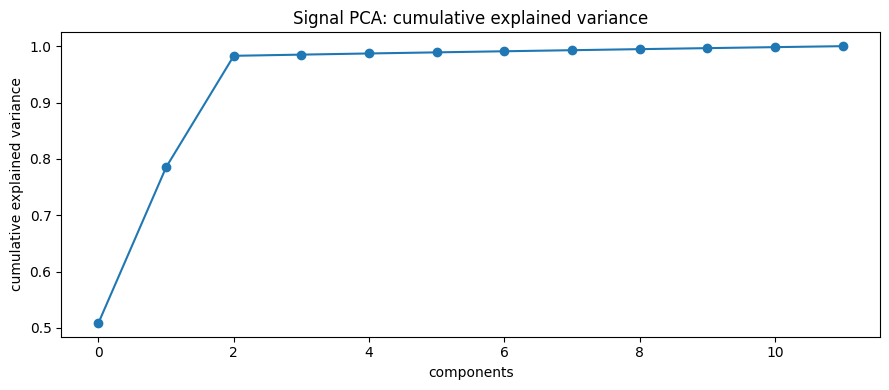

(1500, 3)

In [19]:
# Create synthetic signals and compress with PCA
# Synthetic "signal" matrix: T x p features with redundancy
T = 1500
p = 12

# Create 3 latent drivers + noise, then mix them into p features
latent = np.random.randn(T, 3)
mix = np.random.randn(3, p)
signals = latent @ mix + 0.3*np.random.randn(T, p)

# PCA via eigen-decomposition of feature covariance
S = np.cov(signals, rowvar=False)
evals_s, evecs_s = np.linalg.eigh(S)
idx = np.argsort(evals_s)[::-1]
evals_s, evecs_s = evals_s[idx], evecs_s[:, idx]

expl = evals_s / evals_s.sum()
plt.figure(figsize=(9,4))
plt.plot(np.cumsum(expl), marker="o")
plt.title("Signal PCA: cumulative explained variance")
plt.xlabel("components")
plt.ylabel("cumulative explained variance")
plt.tight_layout()
plt.show()

# Project signals onto first k components
k = 3
signals_centered = signals - signals.mean(axis=0, keepdims=True)
signals_reduced = signals_centered @ evecs_s[:, :k]  # T x k
signals_reduced.shape

---

## 8. The Efficient Frontier — Full Workflow

### The Core Insight

The efficient frontier is not a single formula. It is a **workflow** — a process of converting beliefs into decisions and then examining the full spectrum of consequences.

> Every point on the frontier answers the question: *"Given my beliefs about returns and risk, what is the best possible portfolio at this risk level?"*

---

### The Full Workflow

| Step | Action | Tools |
|------|--------|-------|
| 1 | Estimate $\hat{\mu}$ from historical or factor data | Sample mean, shrinkage |
| 2 | Estimate $\hat{\Sigma}$ | Sample covariance, Ledoit–Wolf |
| 3 | Define constraint set $\mathcal{W}$ | Long-only, leverage limits, sector caps |
| 4 | Sweep target returns $r_{\text{target}}$ | Grid of values |
| 5 | Solve $\min_w w^\top \hat{\Sigma} w$ at each target | CVXPY, scipy, or sampling |
| 6 | Plot volatility vs. expected return | Efficient frontier curve |
| 7 | Select portfolio | Max Sharpe, min variance, risk budget |

---

### What the Frontier Teaches

- **No free lunch**: You cannot move outside the frontier without changing assumptions or constraints
- **Geometry is assumption-driven**: A different $\hat{\Sigma}$ produces a different frontier — the curve is a model, not a fact
- **The frontier is a hypothesis**: Changing the estimation window or shrinkage target shifts every point on it

---

### Professional Practice vs. Teaching

| Teaching (this notebook) | Production System |
|--------------------------|------------------|
| Random simplex sampling | Convex solver (CVXPY) |
| Sample covariance | Ledoit–Wolf or factor model |
| Unconstrained (approx.) | Full constraint set |
| Equal transaction costs | Explicit cost model |
| Static frontier | Rolling / adaptive frontier |

> **The geometry is identical in both cases.** Learning the intuition here prepares you to use production tools correctly — because you understand what they are solving and why.


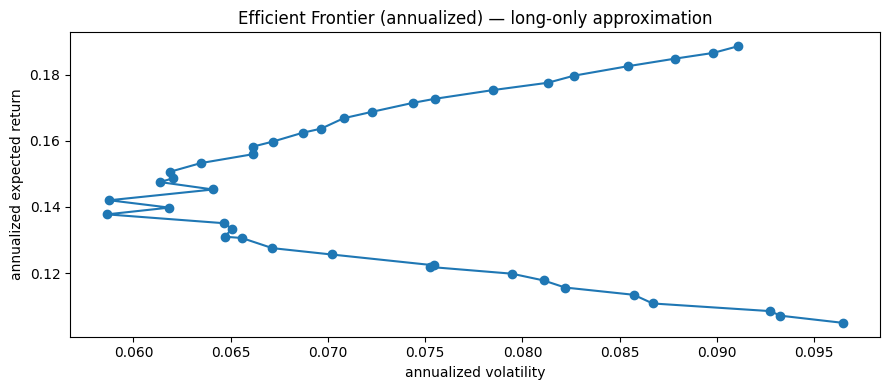

In [20]:
# Annualized and plot frontier
# Convert frontier to annualized figures (approx)
front_ret_ann = np.array([annualize_return(r) for r in frontier_rets])
front_vol_ann = np.array([annualize_vol(v) for v in frontier_vols])

plt.figure(figsize=(9,4))
plt.plot(front_vol_ann, front_ret_ann, marker="o")
plt.title("Efficient Frontier (annualized) — long-only approximation")
plt.xlabel("annualized volatility")
plt.ylabel("annualized expected return")
plt.tight_layout()
plt.show()

---

## Closing Reflection — The Geometry of Risk

Linear algebra transforms "many assets" into a single object you can reason about precisely.

| Concept | What It Gives You |
|---------|------------------|
| **Vectors** | Precise representation of positions and signals |
| **Matrices** | History, relationships, and linear transformations |
| **Eigenvectors** | Hidden risk directions invisible to naive diversification |
| **Quadratic forms** | Exact measure of portfolio fragility and risk attribution |
| **Optimization** | The discipline of turning beliefs into decisions |

---

### The Professional Mindset

> A good trader respects **uncertainty**.
> A good quant respects **geometry**.

These are not separate skills. The best practitioners hold both simultaneously:

1. **Vectors encode positions** — be explicit about what you own and at what weight
2. **Matrices encode history** — your covariance model is your belief about the future
3. **Eigenvectors expose concentration** — diversification is meaningless unless it's across uncorrelated directions
4. **Optimization is an honesty machine** — it forces assumptions into the open
5. **The frontier is a model** — not a guarantee

---

### Looking Ahead

In the next module, we move to **calculus and differential equations** — the language of change. We will see how rates of change (Greeks in options, durations in bonds) and stochastic differential equations (Brownian motion, Itô's Lemma) connect to the linear structures we built here.

> *The geometry of risk is the foundation. Calculus is what makes it dynamic.*

---
*Next: Module 1.3 — Calculus & Differential Equations*
